In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (10,6)
plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
df = pd.read_csv('/kaggle/input/salary-prediction-dataset/Salary_Data.csv')

df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [3]:
# Check missing values
df.isnull().sum()

# Check duplicates
df.duplicated().sum()


np.int64(0)

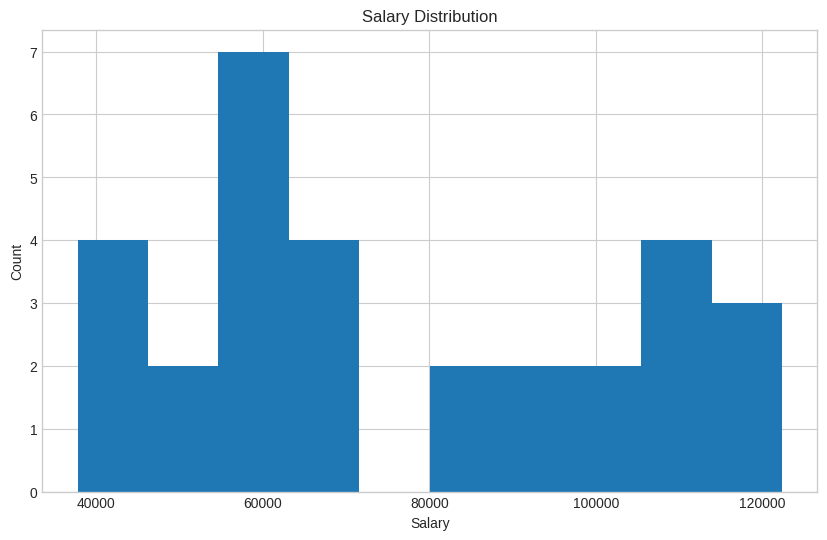

In [4]:
plt.hist(df['Salary'], bins=10)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Count')
plt.show()


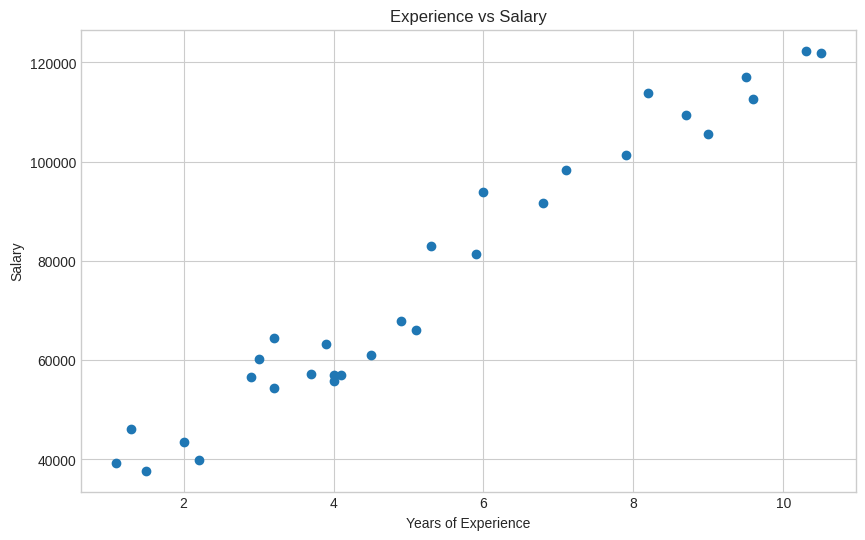

In [5]:
plt.scatter(df['YearsExperience'], df['Salary'])
plt.title('Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()


In [6]:
df.corr()


,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


In [7]:
X = df[['YearsExperience']]
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)


In [8]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lr = lin_reg.predict(X_test)


In [9]:
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R²:", r2_score(y_test, y_pred_lr))


MAE: 4956.5232614449005
RMSE: 5941.540110706558
R²: 0.9553063138044949


In [10]:
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

poly_model.fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_test)


In [11]:
print("Polynomial MAE:", mean_absolute_error(y_test, y_pred_poly))
print("Polynomial RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly)))
print("Polynomial R²:", r2_score(y_test, y_pred_poly))


Polynomial MAE: 4960.229778669015
Polynomial RMSE: 5941.285516660327
Polynomial R²: 0.9553101439570846


In [12]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)


In [13]:
lasso = Lasso(alpha=100)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)


In [14]:
models = {
    'Linear': y_pred_lr,
    'Polynomial': y_pred_poly,
    'Ridge': y_pred_ridge,
    'Lasso': y_pred_lasso
}

for name, preds in models.items():
    print(f"{name} R²:", r2_score(y_test, preds))


Linear R²: 0.9553063138044949
Polynomial R²: 0.9553101439570846
Ridge R²: 0.9550740664449615
Lasso R²: 0.9552653741598193


In [15]:
future_exp = np.array([[11], [12], [15], [20]])

future_salary = poly_model.predict(future_exp)

forecast_df = pd.DataFrame({
    'YearsExperience': future_exp.flatten(),
    'PredictedSalary': future_salary.astype(int)
})

forecast_df


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


,YearsExperience,PredictedSalary
0,11,129559
1,12,139291
2,15,168805
3,20,219047


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


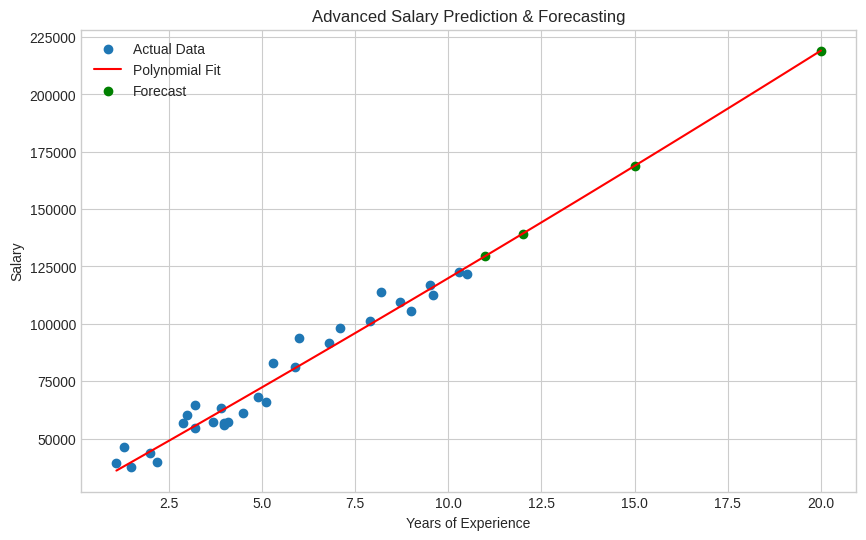

In [16]:
X_range = np.linspace(df['YearsExperience'].min(), 20, 100).reshape(-1,1)
y_range = poly_model.predict(X_range)

plt.scatter(df['YearsExperience'], df['Salary'], label='Actual Data')
plt.plot(X_range, y_range, color='red', label='Polynomial Fit')
plt.scatter(future_exp, future_salary, color='green', label='Forecast')
plt.legend()
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Advanced Salary Prediction & Forecasting')
plt.show()
